# EDA — Support Ticket Priority Classifier

Phase 2 (Person 2): class distribution, text length, and label quality checks on the raw dataset
before handing off to preprocessing (Phase 3) and the Bi-LSTM model (Phase 4-6).

**Dataset:** `customer-support-ticket-dataset` (Kaggle, muqaddasejaz) — 8,469 tickets.
See `README.md` for why this replaced the 50K-row dataset named in the original project brief.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/raw/customer_support_tickets.csv")
print(df.shape)
df.head(3)

(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


## 1. Missing values

In [2]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Resolution                      5700
Time to Resolution              5700
Customer Satisfaction Rating    5700
First Response Time             2819
dtype: int64

`Resolution`, `Time to Resolution`, and `Customer Satisfaction Rating` are only populated for
already-resolved tickets — not relevant to priority classification, since at triage time a new
ticket hasn't been resolved yet. `First Response Time` has some gaps too. None of these are
inputs to the model (we only use `Ticket Description` / `Ticket Subject`), so they don't block
preprocessing.

## 2. Priority class distribution (target variable)

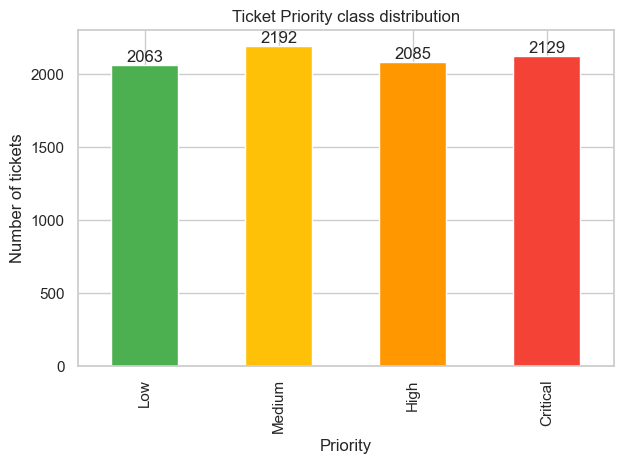

Ticket Priority
Low         2063
Medium      2192
High        2085
Critical    2129
Name: count, dtype: int64

In [3]:
order = ["Low", "Medium", "High", "Critical"]
counts = df["Ticket Priority"].value_counts().reindex(order)

ax = counts.plot(kind="bar", color=["#4CAF50", "#FFC107", "#FF9800", "#F44336"])
ax.set_title("Ticket Priority class distribution")
ax.set_xlabel("Priority")
ax.set_ylabel("Number of tickets")
for i, v in enumerate(counts):
    ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

counts

Classes are well balanced (~2,000–2,200 each, ±3% of the mean) — no class-weighting or
resampling needed before training the Bi-LSTM.

## 3. Text length analysis

In [4]:
df["desc_word_count"] = df["Ticket Description"].str.split().str.len()
df["desc_char_count"] = df["Ticket Description"].str.len()

df[["desc_word_count", "desc_char_count"]].describe()

,desc_word_count,desc_char_count
count,8469.000000,8469.000000
mean,46.467352,289.821939
std,8.461730,43.593954
min,21.000000,151.000000
25%,43.000000,273.000000
50%,49.000000,298.000000
75%,52.000000,318.000000
max,63.000000,397.000000


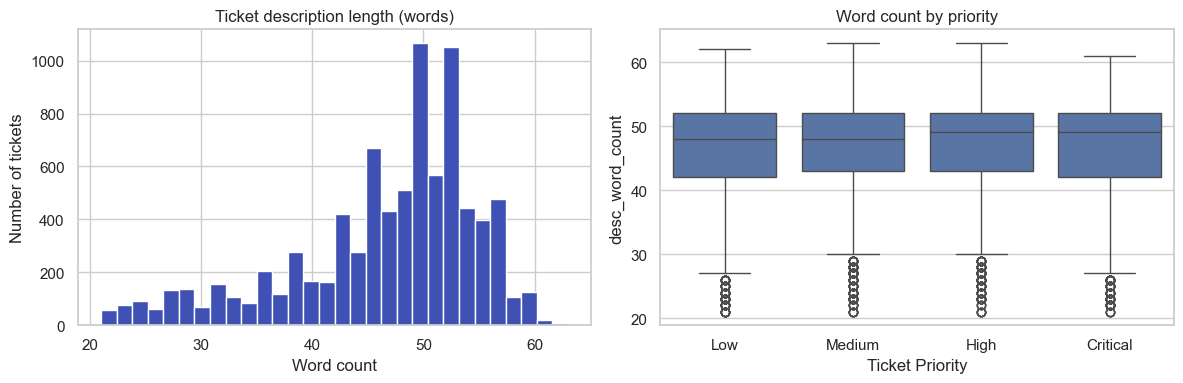

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["desc_word_count"], bins=30, color="#3F51B5")
axes[0].set_title("Ticket description length (words)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of tickets")

sns.boxplot(data=df, x="Ticket Priority", y="desc_word_count", order=order, ax=axes[1])
axes[1].set_title("Word count by priority")

plt.tight_layout()
plt.savefig("text_length.png", dpi=150)
plt.show()

Word count is near-identical across priority classes (median ~45 words for all four) — the
model has to learn from wording/semantics, not just length. This sets `MAX_SEQ_LEN`: the 95th
percentile is computed below and is what Phase 3 preprocessing should pad/truncate to.

In [6]:
p95 = int(df["desc_word_count"].quantile(0.95))
p99 = int(df["desc_word_count"].quantile(0.99))
print(f"95th percentile word count: {p95}")
print(f"99th percentile word count: {p99}")
print(f"max word count: {df['desc_word_count'].max()}")

95th percentile word count: 57
99th percentile word count: 59
max word count: 63


## 4. Label / text quality check

### 4a. Duplicate ticket descriptions

In [7]:
n_dupes = df["Ticket Description"].duplicated().sum()
print(f"Exact duplicate descriptions: {n_dupes} ({n_dupes / len(df):.1%} of rows)")

df[df["Ticket Description"].duplicated(keep=False)]["Ticket Description"].value_counts().head(5)

Exact duplicate descriptions: 392 (4.6% of rows)


Ticket Description
I'm having an issue with the {product_purchased}. Please assist. This problem started occurring after the recent software update. I haven't made any other changes to the device.                    25
I'm having an issue with the {product_purchased}. Please assist. I need assistance as soon as possible because it's affecting my work and productivity.                                              25
I'm having an issue with the {product_purchased}. Please assist. I'm concerned about the security of my {product_purchased} and would like to ensure that my data is safe.                           25
I'm having an issue with the {product_purchased}. Please assist. I've already contacted customer support multiple times, but the issue remains unresolved.                                           24
I'm having an issue with the {product_purchased}. Please assist. I've noticed a peculiar error message popping up on my {product_purchased} screen. It says '{error_message}'. What d

~5% of descriptions are exact duplicates of another row (same templated sentence reused
across different customers/products). Not enough to drop outright, but Juan José should dedupe
the *train* split only if the same exact string appears in both train and val/test (otherwise
it's a near-trivial leak across splits).

### 4b. Unfilled template placeholders

In [8]:
import re

placeholder_pattern = re.compile(r"\{[a-z_]+\}")
has_placeholder = df["Ticket Description"].str.contains(placeholder_pattern)
print(f"Descriptions containing a literal '{{placeholder}}' token: {has_placeholder.sum()} ({has_placeholder.mean():.1%})")

sample_placeholders = df.loc[has_placeholder, "Ticket Description"].str.findall(placeholder_pattern).explode().value_counts()
sample_placeholders

Descriptions containing a literal '{placeholder}' token: 8469 (100.0%)


Ticket Description
{product_purchased}            13873
{error_message}                  472
{product_id}                      52
{product_name}                    34
{product}                         13
                               ...  
{product_purchased_product}        1
{product_purchased_payment}        1
{product_purchased_number}         1
{purchased_name}                   1
{product_purchased_amount}         1
Name: count, Length: 156, dtype: int64

**This is the most important finding for preprocessing.** This dataset was generated from a
template, and **100% of descriptions** contain at least one literal unfilled token
(e.g. `{product_purchased}`, `{error_message}`) instead of the real value — this isn't an edge
case, it's universal. Two options for Phase 3:

1. **Strip/normalize** the placeholder tokens (e.g. replace `{product_purchased}` with the
   actual `Product Purchased` column value, or just remove the braces) so the embedding layer
   doesn't waste a vocab slot on literal `{`/`}` characters.
2. **Leave as-is** — since the noise is spread roughly evenly across all 4 priority classes
   (check below), it likely won't bias the model, just adds a bit of irrelevant vocabulary.

Recommendation: option 1 (cheap to do in `preprocessing.py`, slightly cleaner embeddings).

In [9]:
pd.crosstab(has_placeholder, df["Ticket Priority"], normalize="columns")

Ticket Priority,Critical,High,Low,Medium
Ticket Description,,,,
True,1.0,1.0,1.0,1.0


## 5. Candidate field for `department` (API contract)

The API contract needs a `department` field, but this dataset has no such column. The closest
proxy is `Ticket Type`.

**Resolved:** `department` is a plain lookup from `Ticket Type` (see `backend/department_mapping.py`),
not a second model output — `Ticket Type` is already known per ticket, not something that needs
inferring from text, so the Bi-LSTM only needs to predict `priority`.

| Ticket Type | → Department |
|---|---|
| Technical issue | Technical Support |
| Billing inquiry | Billing |
| Refund request | Billing |
| Cancellation request | Customer Retention |
| Product inquiry | Sales |

In [10]:
df["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

## Summary — handoff notes for Juan José

- **Classes:** balanced 4-class target (`Ticket Priority`), no resampling needed.
- **MAX_SEQ_LEN:** use the 95th-percentile word count computed above (see section 3) for padding.
- **Preprocessing:** strip/normalize `{placeholder}` tokens before tokenizing (section 4b).
- **Duplicates:** ~5% exact-duplicate descriptions — dedupe across train/val/test split boundaries
  to avoid leakage.
- **`department` field:** no direct column exists; team needs to agree on a `Ticket Type` →
  department mapping (section 5) before the API contract can be fully implemented.